In [1]:
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# ---------------------------------------------------
# Helpers
# ---------------------------------------------------

def sanity_check(adata, color=None):
    print("\n======================")
    print("🔍   ANNDATA CHECK")
    print("======================")
    print(f"Shape: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
    print("obs columns:", list(adata.obs.columns))
    print("obsm keys:", list(adata.obsm.keys()))

    if color is not None and color in adata.obs:
        print(f"\nColumn '{color}': {adata.obs[color].nunique()} unique values")
        print(f"Missing: {adata.obs[color].isna().sum():,}")
    elif color is not None:
        print(f"\n⚠️ Column '{color}' NOT FOUND")

    if "X_umap" in adata.obsm:
        print("UMAP present:", adata.obsm["X_umap"].shape)
    else:
        print("No UMAP yet")
    print("======================\n")


def neighbors_umap(adata, use_rep="concept_mean_embedding"):
    emb = adata.obsm[use_rep]      # shape: (n_cells, 128)

    # 1) Run PCA on the embedding directly
    print(f"Running PCA on {use_rep} …")
    pca = sc.tl.pca(emb, n_comps=50, svd_solver="arpack", copy=True)
    
    # Store PCA result in adata.obsm
    adata.obsm["X_pca_emb"] = pca

    # 2) Neighbors + UMAP on PCA of embedding
    print("PP Neighbors on PCA of embedding…")
    sc.pp.neighbors(adata, use_rep="X_pca_emb")

    print("Computing UMAP…")
    sc.tl.umap(adata, min_dist=0.3, random_state=0)



    """print("PP Neighbors on PCA…")
    sc.pp.neighbors(adata, use_rep="X_pca")

    print("Computing UMAP…")
    sc.tl.umap(adata, min_dist=0.3, random_state=0)"""



def plot_umap(adata, color, palette=None, title=None, out_png=None):
    fig = sc.pl.umap(
        adata,
        color=color,
        title=title,
        frameon=False,
        palette=palette,
        show=False,
        return_fig=True,
    )
    plt.show()

    if out_png:
        fig.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"Saved: {out_png}")


cell_type_palette = {'ABCs': '#023fa5',
 'Astrocytes': '#7d87b9',
 'Astroependymal': '#bec1d4',
 'BAMs': '#d6bcc0',
 'Bergmann': '#bb7784',
 'Choroid-Plexus': '#8e063b',
 'ECs': '#4a6fe3',
 'Ependymal': '#8595e1',
 'Immune-Other': '#b5bbe3',
 'Microglia': '#e6afb9',
 'Neurons-Dopa': '#e07b91',
 'Neurons-Gaba': '#d33f6a',
 'Neurons-Glut': '#11c638',
 'Neurons-Glyc-Gaba': '#8dd593',
 'Neurons-Granule-Immature': '#c6dec7',
 'Neurons-Other': '#ead3c6',
 'OECs': '#f0b98d',
 'OPCs': '#ef9708',
 'Oligodendrocytes': '#0fcfc0',
 'Pericytes': '#9cded6',
 'SMCs': '#d5eae7',
 'Tanycytes': '#f3e1eb',
 'Undefined': '#f6c4e1',
 'VLMCs': '#f79cd4'}


In [2]:
#----------------------------------
# Load Zhuang embeddings
# ---------------------------------------------------

zhuang_adata_path = "/p/project1/hai_fzj_bda/spitzer2/point_transformer/data/raw/Zhuang-ABCA-1_concept_embeddings.h5ad"
print(f"📂 Loading {zhuang_adata_path}")
zhuang_adata = sc.read(zhuang_adata_path)

sanity_check(zhuang_adata)

# ---------------------------------------------------
# Prepare IDs
# ---------------------------------------------------

# The index of your adata is in .obs["cell_label"]
zhuang_adata.obs["cell_id"] = zhuang_adata.obs.index.astype(str)

# ---------------------------------------------------
# Subsample
# ---------------------------------------------------

print("📉 Subsampling to 100k…")
sc.pp.subsample(zhuang_adata, n_obs=100000, random_state=0)
sanity_check(zhuang_adata)

📂 Loading /p/project1/hai_fzj_bda/spitzer2/point_transformer/data/raw/Zhuang-ABCA-1_concept_embeddings.h5ad

🔍   ANNDATA CHECK
Shape: 4,167,870 cells × 1,122 genes
obs columns: ['abc_sample_id', 'brain_section_label', 'brain_section_label_adata', 'class', 'class_color', 'cluster', 'cluster_alias', 'cluster_color', 'cluster_confidence_score', 'donor_genotype', 'donor_label', 'donor_sex', 'feature_matrix_label', 'high_quality_transfer', 'neurotransmitter', 'neurotransmitter_color', 'parcellation_category', 'parcellation_category_color', 'parcellation_division', 'parcellation_division_color', 'parcellation_index', 'parcellation_organ', 'parcellation_organ_color', 'parcellation_structure', 'parcellation_structure_color', 'parcellation_substructure', 'parcellation_substructure_color', 'subclass', 'subclass_color', 'subclass_confidence_score', 'supertype', 'supertype_color', 'x', 'x_ccf', 'y', 'y_ccf', 'z', 'z_ccf']
obsm keys: ['concept_cls_embedding', 'concept_mean_embedding']
No UMAP yet



In [6]:
# ---------------------------------------------------
# Load and fix Zhuang annotations
# ---------------------------------------------------
zhuang_annot_path = "/p/project1/hai_fzj_bda/salg1/cellseg-benchmark/data_dir/samples/zhuang/results/merfish/cell_type_annotation/adata_obs_annotated.csv"
print(f"📂 Loading annotation: {zhuang_annot_path}")

zhuang_ann = pd.read_csv(zhuang_annot_path)

# Strip suffix "-Zhuang-ABCA1"
zhuang_ann["cell_id"] = zhuang_ann["cell_id"].apply(lambda x: f"{x}-Zhuang")

# Rename so merge works
zhuang_ann["cell_type"] = zhuang_ann["cell_type_mmc_raw"]

# ---------------------------------------------------
# Merge
# ---------------------------------------------------

zhuang_adata.obs = zhuang_adata.obs.merge(
    zhuang_ann[["cell_id", "cell_type"]],
    left_on="cell_id",
    right_on="base_id",
    how="left"
)

sanity_check(zhuang_adata, color="cell_type")

📂 Loading annotation: /p/project1/hai_fzj_bda/salg1/cellseg-benchmark/data_dir/samples/zhuang/results/merfish/cell_type_annotation/adata_obs_annotated.csv

🔍   ANNDATA CHECK
Shape: 100,000 cells × 1,122 genes
obs columns: ['abc_sample_id', 'brain_section_label', 'brain_section_label_adata', 'class', 'class_color', 'cluster', 'cluster_alias', 'cluster_color', 'cluster_confidence_score', 'donor_genotype', 'donor_label', 'donor_sex', 'feature_matrix_label', 'high_quality_transfer', 'neurotransmitter', 'neurotransmitter_color', 'parcellation_category', 'parcellation_category_color', 'parcellation_division', 'parcellation_division_color', 'parcellation_index', 'parcellation_organ', 'parcellation_organ_color', 'parcellation_structure', 'parcellation_structure_color', 'parcellation_substructure', 'parcellation_substructure_color', 'subclass', 'subclass_color', 'subclass_confidence_score', 'supertype', 'supertype_color', 'x', 'x_ccf', 'y', 'y_ccf', 'z', 'z_ccf', 'cell_id', 'base_id', 'cell_typ

Running PCA on concept_cls_embedding …
PP Neighbors on PCA of embedding…
Computing UMAP…


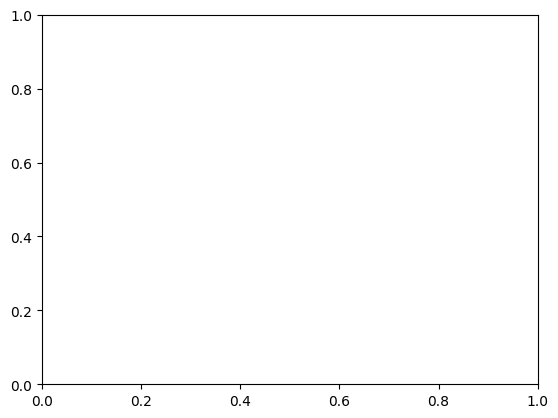

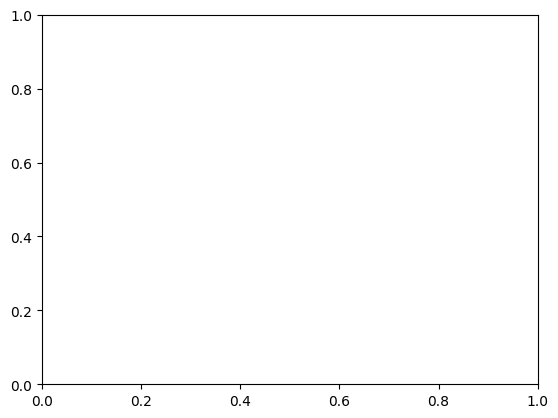

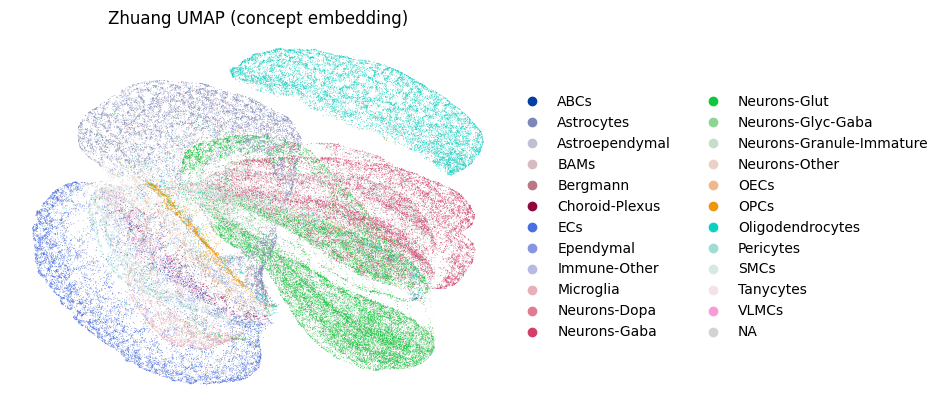

🎉 DONE!


In [7]:
# ---------------------------------------------------
# Compute UMAP on concept embedding
# ---------------------------------------------------

neighbors_umap(zhuang_adata, use_rep="concept_cls_embedding") # use concept embeddingor or "concept_mean_embedding"

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
title = "Zhuang UMAP (concept embedding)"
out_png = os.path.join(os.getcwd(), "zhuang_umap_concept_cls_pca.png")

plot_umap(
    zhuang_adata,
    color="cell_type",
    title=title,
    palette=cell_type_palette,  # add your palette if you want
)

print("🎉 DONE!")


In [8]:
zhuang_adata_2 = zhuang_adata.copy()
sc.pp.neighbors(zhuang_adata_2, use_rep="concept_mean_embedding", n_neighbors=30)  # try 15, 50 too
sc.tl.umap(zhuang_adata_2, min_dist=0.4)

/p/scratch/cjinm16/dipippo1/envs/scConcept-1/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [9]:
import scib

zhuang_adata_clisi = scib.metrics.clisi_graph(
    zhuang_adata_2,
    label_key="cell_type",   # correct!
    type_="knn"
)

print("cLISI:", zhuang_adata_clisi)

cLISI: 0.9650622780470152


In [10]:
# ---------------------------------------------------
# Load and merge Zeng annotations
# ---------
zeng_adata_path = "/p/project1/hai_fzj_bda/spitzer2/point_transformer/data/raw/Zeng_concept_embeddings.h5ad"
print(f"📂 Loading {zeng_adata_path}")
zeng_adata = sc.read(zeng_adata_path)

sanity_check(zeng_adata)

print("📉 Subsampling to 100k…")
sc.pp.subsample(zeng_adata, n_obs=100000, random_state=0)
sanity_check(zeng_adata)

zeng_annot_path = "/p/project1/hai_fzj_bda/salg1/cellseg-benchmark/data_dir/samples/zeng/results/merfish/cell_type_annotation/adata_obs_annotated.csv"
print(f"📂 Loading annotation: {zeng_annot_path}")

zeng_ann = pd.read_csv(zeng_annot_path)

print("\n🔍 First Zeng annotation IDs:")
print(zeng_ann["cell_id"].head(20))

# No suffix → cell_id matches directly
# Rename annotation column
zeng_adata.obs["cell_id"] = zeng_adata.obs_names.astype(str)
zeng_ann = zeng_ann.rename(columns={"cell_type_mmc_raw": "cell_type"})

# Merge using exact IDs
zeng_adata.obs = zeng_adata.obs.merge(
    zeng_ann[["cell_id", "cell_type"]],
    on="cell_id",
    how="left"
)

sanity_check(zeng_adata, color="cell_type")


📂 Loading /p/project1/hai_fzj_bda/spitzer2/point_transformer/data/raw/Zeng_concept_embeddings.h5ad


KeyboardInterrupt: 

In [ ]:

# ---------------------------------------------------
# Compute UMAP on concept embedding
# ---------------------------------------------------

neighbors_umap(zeng_adata, use_rep="concept_mean_embedding") # use concept embeddingor or "concept_mean_embedding"

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

title = "Zeng UMAP (concept embedding)"
out_png = os.path.join(os.getcwd(), "zeng_umap_concept_mean_pca.png")

plot_umap(
    zeng_adata,
    color="cell_type",
    title=title,
    palette=cell_type_palette,  # add your palette if you want
    out_png = out_png
)

print("🎉 DONE!")

In [11]:
#!/usr/bin/env python

import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Helpers
# ---------------------------------------------------

def sanity_check(adata, color=None, name="adata"):
    print("\n======================")
    print(f"🔍   ANNDATA CHECK ({name})")
    print("======================")
    print(f"Shape: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
    print("obs columns:", list(adata.obs.columns))
    print("obsm keys:", list(adata.obsm.keys()))

    if color is not None:
        if color in adata.obs:
            print(f"\nColumn '{color}': {adata.obs[color].nunique()} unique values")
            print(f"Missing: {adata.obs[color].isna().sum():,}")
        else:
            print(f"\n⚠️ Column '{color}' NOT FOUND in obs")

    if "X_umap" in adata.obsm:
        print("UMAP present:", adata.obsm["X_umap"].shape)
    else:
        print("No UMAP yet")
    print("======================\n")


def neighbors_umap_on_embedding(adata, use_rep="concept_mean_embedding", n_pcs=50, min_dist=0.3):
    """
    Run PCA on adata.obsm[use_rep], store as X_pca_emb, then neighbors+UMAP.
    """
    print(f"⚙️ Using embedding key: {use_rep}")
    if use_rep not in adata.obsm:
        raise KeyError(f"{use_rep} not found in adata.obsm")

    emb = adata.obsm[use_rep]   # (n_cells, dim)
    print(f"Embedding shape: {emb.shape}")

    print(f"📉 Running PCA on {use_rep} → {n_pcs} components…")
    X_pca = sc.tl.pca(emb, n_comps=n_pcs, svd_solver="arpack", copy=True)
    adata.obsm["X_pca_emb"] = X_pca

    print("👥 Computing neighbors on PCA of embedding…")
    sc.pp.neighbors(adata, use_rep="X_pca_emb")

    print("🌀 Computing UMAP…")
    sc.tl.umap(adata, min_dist=min_dist, random_state=0)


def plot_umap(adata, color, palette=None, title=None, out_png=None):
    if title is None:
        title = f"UMAP colored by {color}"

    print(f"🎨 Plotting UMAP colored by '{color}'…")
    fig = sc.pl.umap(
        adata,
        color=color,
        title=title,
        frameon=False,
        palette=palette,
        show=False,
        return_fig=True,
    )
    plt.show()

    if out_png is not None:
        fig.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"💾 Saved: {out_png}")


# Palette for cell types (same as before)
cell_type_palette = {
    'ABCs': '#023fa5',
    'Astrocytes': '#7d87b9',
    'Astroependymal': '#bec1d4',
    'BAMs': '#d6bcc0',
    'Bergmann': '#bb7784',
    'Choroid-Plexus': '#8e063b',
    'ECs': '#4a6fe3',
    'Ependymal': '#8595e1',
    'Immune-Other': '#b5bbe3',
    'Microglia': '#e6afb9',
    'Neurons-Dopa': '#e07b91',
    'Neurons-Gaba': '#d33f6a',
    'Neurons-Glut': '#11c638',
    'Neurons-Glyc-Gaba': '#8dd593',
    'Neurons-Granule-Immature': '#c6dec7',
    'Neurons-Other': '#ead3c6',
    'OECs': '#f0b98d',
    'OPCs': '#ef9708',
    'Oligodendrocytes': '#0fcfc0',
    'Pericytes': '#9cded6',
    'SMCs': '#d5eae7',
    'Tanycytes': '#f3e1eb',
    'Undefined': '#f6c4e1',
    'VLMCs': '#f79cd4',
}


if True:
    # ---------------------------------------------------
    # Paths
    # ---------------------------------------------------
    ZHUANG_PATH = "/p/project1/hai_fzj_bda/spitzer2/point_transformer/data/raw/Zhuang-ABCA-1_concept_embeddings.h5ad"
    ZENG_PATH   = "/p/project1/hai_fzj_bda/spitzer2/point_transformer/data/raw/Zeng_concept_embeddings.h5ad"

    ZHUANG_ANN_PATH = "/p/project1/hai_fzj_bda/salg1/cellseg-benchmark/data_dir/samples/zhuang/results/merfish/cell_type_annotation/adata_obs_annotated.csv"
    ZENG_ANN_PATH   = "/p/project1/hai_fzj_bda/salg1/cellseg-benchmark/data_dir/samples/zeng/results/merfish/cell_type_annotation/adata_obs_annotated.csv"

    # Optional subsample per-dataset to avoid giant RAM usage
    SUBSAMPLE_ZHUANG = 100_000
    SUBSAMPLE_ZENG   = 100_000

    # ---------------------------------------------------
    # Load ZHUANG
    # ---------------------------------------------------
    print(f"📂 Loading Zhuang: {ZHUANG_PATH}")
    zhuang = sc.read(ZHUANG_PATH)
    zhuang.obs_names = zhuang.obs_names.astype(str)
    zhuang.obs["cell_id_raw"] = zhuang.obs_names

    sanity_check(zhuang, name="Zhuang (original)")

    # Attach "-Zhuang" suffix to obs_names and define cell_id
    zhuang.obs_names = zhuang.obs["cell_id_raw"] + "-Zhuang"
    zhuang.obs["cell_id"] = zhuang.obs_names

    # Subsample Zhuang
    if zhuang.n_obs > SUBSAMPLE_ZHUANG:
        print(f"📉 Subsampling Zhuang to {SUBSAMPLE_ZHUANG} cells…")
        sc.pp.subsample(zhuang, n_obs=SUBSAMPLE_ZHUANG, random_state=0)

    sanity_check(zhuang, name="Zhuang (after subsample)")

    # Load Zhuang annotation
    print(f"📂 Loading Zhuang annotations: {ZHUANG_ANN_PATH}")
    z_ann = pd.read_csv(ZHUANG_ANN_PATH)

    # Original Zhuang ann cell_id looks like: "12345-Zhuang-ABCA1"
    z_ann["base_id"] = z_ann["cell_id"].astype(str).str.split("-").str[0]
    z_ann["cell_id_combined"] = z_ann["base_id"] + "-Zhuang"
    z_ann = z_ann.rename(columns={"cell_type_mmc_raw": "cell_type"})

    # Merge
    zhuang.obs = zhuang.obs.merge(
        z_ann[["cell_id_combined", "cell_type"]],
        left_on="cell_id",
        right_on="cell_id_combined",
        how="left"
    )
    zhuang.obs.drop(columns=["cell_id_combined"], inplace=True)

    sanity_check(zhuang, color="cell_type", name="Zhuang (with cell_type)")




📂 Loading Zhuang: /p/project1/hai_fzj_bda/spitzer2/point_transformer/data/raw/Zhuang-ABCA-1_concept_embeddings.h5ad

🔍   ANNDATA CHECK (Zhuang (original))
Shape: 4,167,870 cells × 1,122 genes
obs columns: ['abc_sample_id', 'brain_section_label', 'brain_section_label_adata', 'class', 'class_color', 'cluster', 'cluster_alias', 'cluster_color', 'cluster_confidence_score', 'donor_genotype', 'donor_label', 'donor_sex', 'feature_matrix_label', 'high_quality_transfer', 'neurotransmitter', 'neurotransmitter_color', 'parcellation_category', 'parcellation_category_color', 'parcellation_division', 'parcellation_division_color', 'parcellation_index', 'parcellation_organ', 'parcellation_organ_color', 'parcellation_structure', 'parcellation_structure_color', 'parcellation_substructure', 'parcellation_substructure_color', 'subclass', 'subclass_color', 'subclass_confidence_score', 'supertype', 'supertype_color', 'x', 'x_ccf', 'y', 'y_ccf', 'z', 'z_ccf', 'cell_id_raw']
obsm keys: ['concept_cls_embeddin

In [12]:
if True:
    # ---------------------------------------------------
    # Load ZENG
    # ---------------------------------------------------
    print(f"📂 Loading Zeng: {ZENG_PATH}")
    zeng = sc.read(ZENG_PATH)
    zeng.obs_names = zeng.obs_names.astype(str)
    zeng.obs["cell_id_raw"] = zeng.obs_names

    sanity_check(zeng, name="Zeng (original)")

    # Attach "-Zeng" suffix
    zeng.obs_names = zeng.obs["cell_id_raw"] + "-Zeng"
    zeng.obs["cell_id"] = zeng.obs_names

    # Subsample Zeng
    if zeng.n_obs > SUBSAMPLE_ZENG:
        print(f"📉 Subsampling Zeng to {SUBSAMPLE_ZENG} cells…")
        sc.pp.subsample(zeng, n_obs=SUBSAMPLE_ZENG, random_state=0)

    
    sanity_check(zeng, name="Zeng (original)")

    # Attach "-Zeng" suffix
    zeng.obs_names = zeng.obs["cell_id_raw"] + "-Zeng"
    zeng.obs["cell_id"] = zeng.obs_names

    # Subsample Zeng
    if zeng.n_obs > SUBSAMPLE_ZENG:
        print(f"📉 Subsampling Zeng to {SUBSAMPLE_ZENG} cells…")
        sc.pp.subsample(zeng, n_obs=SUBSAMPLE_ZENG, random_state=0)

    sanity_check(zeng, name="Zeng (after subsample)")

    # Load Zeng annotation
    print(f"📂 Loading Zeng annotations: {ZENG_ANN_PATH}")
    ze_ann = pd.read_csv(ZENG_ANN_PATH)

    # Zeng IDs are plain numeric, we add "-Zeng" to match
    ze_ann["cell_id_combined"] = ze_ann["cell_id"].astype(str) + "-Zeng"
    ze_ann = ze_ann.rename(columns={"cell_type_mmc_raw": "cell_type"})

    # Merge
    zeng.obs = zeng.obs.merge(
        ze_ann[["cell_id_combined", "cell_type"]],
        left_on="cell_id",
        right_on="cell_id_combined",
        how="left"
    )
    zeng.obs.drop(columns=["cell_id_combined"], inplace=True)

    sanity_check(zeng, color="cell_type", name="Zeng (with cell_type)")

📂 Loading Zeng: /p/project1/hai_fzj_bda/spitzer2/point_transformer/data/raw/Zeng_concept_embeddings.h5ad

🔍   ANNDATA CHECK (Zeng (original))
Shape: 4,334,174 cells × 550 genes
obs columns: ['abc_sample_id', 'average_correlation_score', 'brain_section_label', 'brain_section_label_adata', 'class', 'class_color', 'cluster', 'cluster_alias', 'cluster_color', 'donor_genotype', 'donor_label', 'donor_sex', 'feature_matrix_label', 'neurotransmitter', 'neurotransmitter_color', 'parcellation_category', 'parcellation_category_color', 'parcellation_division', 'parcellation_division_color', 'parcellation_index', 'parcellation_organ', 'parcellation_organ_color', 'parcellation_structure', 'parcellation_structure_color', 'parcellation_substructure', 'parcellation_substructure_color', 'subclass', 'subclass_color', 'supertype', 'supertype_color', 'x', 'x_ccf', 'y', 'y_ccf', 'z', 'z_ccf', 'cell_id_raw']
obsm keys: ['concept_cls_embedding', 'concept_mean_embedding']
No UMAP yet

📉 Subsampling Zeng to 100

/tmp/ipykernel_202629/3129963333.py:37: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ze_ann = pd.read_csv(ZENG_ANN_PATH)



🔍   ANNDATA CHECK (Zeng (with cell_type))
Shape: 100,000 cells × 550 genes
obs columns: ['abc_sample_id', 'average_correlation_score', 'brain_section_label', 'brain_section_label_adata', 'class', 'class_color', 'cluster', 'cluster_alias', 'cluster_color', 'donor_genotype', 'donor_label', 'donor_sex', 'feature_matrix_label', 'neurotransmitter', 'neurotransmitter_color', 'parcellation_category', 'parcellation_category_color', 'parcellation_division', 'parcellation_division_color', 'parcellation_index', 'parcellation_organ', 'parcellation_organ_color', 'parcellation_structure', 'parcellation_structure_color', 'parcellation_substructure', 'parcellation_substructure_color', 'subclass', 'subclass_color', 'supertype', 'supertype_color', 'x', 'x_ccf', 'y', 'y_ccf', 'z', 'z_ccf', 'cell_id_raw', 'cell_id', 'cell_type']
obsm keys: ['concept_cls_embedding', 'concept_mean_embedding']

Column 'cell_type': 23 unique values
Missing: 13,654
No UMAP yet



In [13]:
if True:
    # ---------------------------------------------------
    # Concatenate Zhuang + Zeng
    # ---------------------------------------------------
    print("🔗 Concatenating Zhuang + Zeng into one AnnData…")
    combined = zhuang.concatenate(
        zeng,
        batch_key="dataset",
        batch_categories=["Zhuang", "Zeng"],
        index_unique=None,
    )

    sanity_check(combined, color="cell_type", name="Combined (Zhuang + Zeng)")
    print("Unique datasets:", combined.obs["dataset"].unique())
    combined.obs_names_make_unique()  
    sanity_check(combined, color="cell_type", name="Combined (Zhuang + Zeng)")
    print("Unique datasets:", combined.obs["dataset"].unique())

🔗 Concatenating Zhuang + Zeng into one AnnData…


/tmp/ipykernel_202629/2669838195.py:6: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = zhuang.concatenate(
/p/scratch/cjinm16/dipippo1/envs/scConcept-1/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/p/scratch/cjinm16/dipippo1/envs/scConcept-1/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/p/scratch/cjinm16/dipippo1/envs/scConcept-1/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModific


🔍   ANNDATA CHECK (Combined (Zhuang + Zeng))
Shape: 200,000 cells × 477 genes
obs columns: ['abc_sample_id', 'brain_section_label', 'brain_section_label_adata', 'class', 'class_color', 'cluster', 'cluster_alias', 'cluster_color', 'cluster_confidence_score', 'donor_genotype', 'donor_label', 'donor_sex', 'feature_matrix_label', 'high_quality_transfer', 'neurotransmitter', 'neurotransmitter_color', 'parcellation_category', 'parcellation_category_color', 'parcellation_division', 'parcellation_division_color', 'parcellation_index', 'parcellation_organ', 'parcellation_organ_color', 'parcellation_structure', 'parcellation_structure_color', 'parcellation_substructure', 'parcellation_substructure_color', 'subclass', 'subclass_color', 'subclass_confidence_score', 'supertype', 'supertype_color', 'x', 'x_ccf', 'y', 'y_ccf', 'z', 'z_ccf', 'cell_id_raw', 'cell_id', 'cell_type', 'average_correlation_score', 'dataset']
obsm keys: ['concept_cls_embedding', 'concept_mean_embedding']

Column 'cell_type'

/p/scratch/cjinm16/dipippo1/envs/scConcept-1/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
if True:
    
    # ---------------------------------------------------
    # Neighbors + UMAP on concept embedding
    # ---------------------------------------------------
    neighbors_umap_on_embedding(
        combined,
        use_rep="concept_mean_embedding",   # or "concept_cls_embedding"
        n_pcs=50,
        min_dist=0.3,
    )

⚙️ Using embedding key: concept_mean_embedding
Embedding shape: (200000, 128)
📉 Running PCA on concept_mean_embedding → 50 components…
👥 Computing neighbors on PCA of embedding…
🌀 Computing UMAP…


In [14]:
if True:
    
    # ---------------------------------------------------
    # Plot UMAP
    # ---------------------------------------------------
    cwd = os.getcwd()

    # 1) UMAP colored by dataset (Zhuang vs Zeng)
    out_dataset = os.path.join(cwd, "combined_umap_dataset.png")
    plot_umap(
        combined,
        color="dataset",
        palette=None,
        title="Combined UMAP (concept embedding, colored by dataset)",
        out_png=out_dataset,
    )

    # 2) UMAP colored by cell_type
    out_celltype = os.path.join(cwd, "combined_umap_cell_type.png")
    plot_umap(
        combined,
        color="cell_type",
        palette=cell_type_palette,
        title="Combined UMAP (concept embedding, colored by cell_type)",
        out_png=out_celltype,
    )

    print("\n🎉 DONE!")
    print("Figures saved as:")
    print("  -", out_dataset)
    print("  -", out_celltype)


🎨 Plotting UMAP colored by 'dataset'…


KeyError: "Could not find 'umap' or 'X_umap' in .obsm"

In [6]:
import os
import scanpy as sc
import matplotlib.pyplot as plt

def plot_umap_by_cell_type(combined, cell_type_palette, outdir="umap_by_celltype"):
    os.makedirs(outdir, exist_ok=True)

    # Unique cell types
    cell_types = sorted([ct for ct in combined.obs["cell_type"].unique() if pd.notna(ct)])

    print(f"📌 Found {len(cell_types)} cell types to plot.")

    # Loop over cell types
    for ct in cell_types:
        print(f"  → Plotting {ct} ...")

        # Select only cells of this type
        ad = combined[combined.obs["cell_type"] == ct].copy()

        if ad.n_obs < 50:
            print(f"     ⚠️ Skipping {ct}: too few cells ({ad.n_obs})")
            continue

        # Build output path
        out_png = os.path.join(outdir, f"umap_{ct.replace(' ', '_')}.png")

        # Plot UMAP: color by dataset
        fig = sc.pl.umap(
            ad,
            color="dataset",
            title=f"{ct} — Zhuang vs Zeng",
            frameon=False,
            palette={"Zhuang": "#1f77b4", "Zeng": "#ff7f0e"},
            return_fig=True,
            show=False,
        )

        fig.savefig(out_png, dpi=300, bbox_inches="tight")
        plt.close(fig)

    print("\n🎉 DONE! All per-cell-type UMAPs saved in:", outdir)
plot_umap_by_cell_type(
    combined,
    cell_type_palette,
    outdir="umap_split_by_celltype"
)

📌 Found 23 cell types to plot.
  → Plotting ABCs ...


/p/scratch/cjinm16/dipippo1/envs/scConcept-1/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  → Plotting Astrocytes ...


/p/scratch/cjinm16/dipippo1/envs/scConcept-1/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  → Plotting Astroependymal ...
  → Plotting BAMs ...
  → Plotting Bergmann ...


...

/p/scratch/cjinm16/dipippo1/envs/scConcept-1/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  → Plotting SMCs ...
  → Plotting Tanycytes ...


/p/scratch/cjinm16/dipippo1/envs/scConcept-1/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  → Plotting VLMCs ...

🎉 DONE! All per-cell-type UMAPs saved in: umap_split_by_celltype


/p/scratch/cjinm16/dipippo1/envs/scConcept-1/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
import os
print(combined.obs_names.is_unique)

# Must set BEFORE importing scib
os.environ["TMPDIR"] = "/p/scratch/cjinm16/dipippo1/tmp_lisi"
os.makedirs(os.environ["TMPDIR"], exist_ok=True)

import scib
import scanpy as sc



print("Computing neighbors on subsampled data…")
sc.pp.neighbors(
    combined,
    use_rep="concept_cls_embedding",   # MUST point to a valid obsm key
    n_neighbors=30
)

print("Running cLISI…")
clisi = scib.metrics.clisi_graph(
    combined,
    label_key="dataset",
    type_="knn",
)

print("cLISI:", clisi)



In [9]:
from scib_metrics.benchmark import Benchmarker

# 1) Ensure annotation column is string
combined.obs["cell_type_string"] = combined.obs["cell_type"].astype(str)

# 2) Run Benchmarker on your embedding
bm = Benchmarker(
    combined,
    batch_key="dataset",                 # THIS IS THE CORRECT BATCH COLUMN
    label_key="cell_type_string",        # your cell type
    embedding_obsm_keys=["concept_cls_embedding"],  # or "concept_mean_embedding"
    n_jobs=-1,
)

# 3) Benchmark
bm.benchmark()

# 4) Print results
results = bm.get_results()
print(results)


/p/scratch/cjinm16/dipippo1/envs/scConcept-1/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Embeddings:   0%|          | 0/1 [00:01<?, ?it/s]


TypeError: asarray() got an unexpected keyword argument 'copy'